# Explore raw telemetry export: 2026-05-31-18-58

Loads `../data/raw/2026-05-31-18-58.csv`, filters to `data_schema_version == 6`, identifies NaN-containing rows, flattens metadata, removes rows with null values, and summarizes sessions, access tokens, difficulty reached, total time played, and time spent in each challenge label. Each row represents one 10-second telemetry window.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 180)

DATA_PATH = Path("../data/raw/2026-05-31-18-58.csv")
SECONDS_PER_ROW = 10
assert DATA_PATH.exists(), f"Missing data file: {DATA_PATH.resolve()}"


## Load, schema-filter, and inspect NaNs


In [2]:
raw_all = pd.read_csv(DATA_PATH)
raw_all["data_schema_version"] = pd.to_numeric(raw_all["data_schema_version"], errors="coerce")
raw_schema = raw_all[raw_all["data_schema_version"].eq(6)].copy()

nan_rows = raw_schema[raw_schema.isna().any(axis=1)].copy()
print(
    f"Raw rows: {len(raw_all):,} | "
    f"Schema 6 rows: {len(raw_schema):,} | "
    f"Schema 6 rows with any NaN: {len(nan_rows):,}"
)
display(raw_all["data_schema_version"].value_counts(dropna=False).sort_index().to_frame("rows"))
display(nan_rows.head())
display(raw_schema.isna().sum().loc[lambda s: s.gt(0)].to_frame("nan_rows"))


Raw rows: 1,127 | Schema 6 rows: 1,022 | Schema 6 rows with any NaN: 0


,rows
data_schema_version,
2.0,12
3.0,45
5.0,9
6.0,1022
NaN,39


,id,token_used,event_type,metric_value,metadata,created_at,game_version,session_id,game_mode,window_index,window_started_at,window_ended_at,difficulty,score,height_climbed,challenge_label,data_schema_version,device_type,deployment_context


,nan_rows


## Flatten metadata and drop null rows


In [3]:
timestamp_cols = ["created_at", "window_started_at", "window_ended_at"]
for col in timestamp_cols:
    raw_schema[col] = pd.to_datetime(raw_schema[col], errors="coerce", utc=True)

def parse_metadata(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        parsed = value
    else:
        try:
            parsed = json.loads(value)
        except json.JSONDecodeError:
            return {}
    if not isinstance(parsed, dict):
        return {}
    parsed.pop("failed_jump_counts", None)
    return parsed

metadata = pd.json_normalize(raw_schema["metadata"].map(parse_metadata)).add_prefix("meta_")
df = pd.concat([raw_schema.drop(columns=["metadata"]).reset_index(drop=True), metadata.reset_index(drop=True)], axis=1)

for col in [c for c in df.columns if c.endswith("_at") or c == "meta_logged_at"]:
    if df[col].dtype == "object":
        parsed = pd.to_datetime(df[col], errors="coerce", utc=True)
        if parsed.notna().any():
            df[col] = parsed

rows_before_dropna = len(df)
df = df.dropna(axis=0, how="any").reset_index(drop=True)
windows = df[df["event_type"].eq("telemetry_window")].copy()
windows["play_seconds"] = SECONDS_PER_ROW
windows["play_minutes"] = windows["play_seconds"] / 60

print(f"Expanded rows before dropna: {rows_before_dropna:,} | After dropna: {len(df):,} | Telemetry windows: {len(windows):,}")
display(windows.head())
display(windows.dtypes.to_frame("dtype"))


Expanded rows before dropna: 1,022 | After dropna: 1,022 | Telemetry windows: 1,022


,id,token_used,event_type,metric_value,created_at,game_version,session_id,game_mode,window_index,window_started_at,window_ended_at,difficulty,score,height_climbed,challenge_label,data_schema_version,device_type,deployment_context,meta_deaths,meta_logged_at,meta_skip_reward,meta_deaths_total,meta_jump_key_presses,meta_left_key_presses,meta_right_key_presses,meta_skip_reward_total,meta_skipped_platforms,meta_seconds_since_flag,meta_window_duration_ms,meta_previous_difficulty,meta_vertical_position_y,meta_failed_jump_attempts,meta_distinct_failed_jumps,meta_flags_collected_total,meta_new_platforms_reached,meta_platform_gap_y_avg_px,meta_platform_gap_y_max_px,meta_platform_gap_y_min_px,meta_platform_width_avg_px,meta_platform_width_max_px,meta_platform_width_min_px,meta_platform_height_avg_px,meta_platform_height_max_px,meta_platform_height_min_px,meta_window_starting_height,meta_platform_x_shift_max_px,meta_platform_x_shift_min_px,meta_platform_speed_px_per_frame,meta_total_horizontal_movement_px,meta_jumps_landed_on_new_platforms,meta_repeated_failed_jump_attempts,play_seconds,play_minutes
0,005420bc-6601-46d1-a39c-167020a1b0e9,5656,telemetry_window,154,2026-05-30 12:27:47.331740+00:00,v0.15.14,4fb7ae84-6ccd-48fd-9571-d65683a9e440,train,111.0,2026-05-30 12:27:37.353000+00:00,2026-05-30 12:27:47.353000+00:00,10.0,154.0,22954.0,under_challenged,6.0,mobile,deployed,1,2026-05-30 12:27:47.362000+00:00,0,53,4,5,2,0,0,0.393,10000,10,-22219,1,1,207,5,132,144,120,55,80,30,10,10,10,22525,250,200,1.20,1396,5,0,10,0.166667
1,00e009d2-a72c-4902-aed9-e852a92d7e4a,test_01,telemetry_window,8,2026-05-28 18:46:13.139322+00:00,v0.15.10,c06bc4ff-7384-48f3-9a0b-703b27d03933,train,6.0,2026-05-28 18:46:02.797000+00:00,2026-05-28 18:46:12.797000+00:00,7.0,8.0,677.0,appropriately_challenged,6.0,mobile,deployed,0,2026-05-28 18:46:12.810000+00:00,0,2,0,0,0,2,0,48.894,10000,7,70,0,0,8,0,123,133,113,60,87,33,10,10,10,677,223,177,0.95,0,0,0,10,0.166667
2,010b5794-b00e-4689-87b9-592636ce6db5,test_01,telemetry_window,18,2026-05-24 17:54:20.479066+00:00,v0.10.0,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,2.0,2026-05-24 17:54:10.133000+00:00,2026-05-24 17:54:20.133000+00:00,7.0,18.0,1788.0,under_challenged,6.0,desktop,local,0,2026-05-24 17:54:20.148000+00:00,0,0,9,7,4,2,0,0.752,10000,7,-1050,0,0,16,7,123,133,113,60,87,33,10,10,10,1017,223,177,0.95,1485,7,0,10,0.166667
3,01465c08-0829-432b-9bc5-dae97b059127,5656,telemetry_window,187,2026-05-30 12:30:07.329010+00:00,v0.15.14,4fb7ae84-6ccd-48fd-9571-d65683a9e440,train,125.0,2026-05-30 12:29:57.353000+00:00,2026-05-30 12:30:07.353000+00:00,10.0,187.0,27578.0,over_challenged,6.0,mobile,deployed,2,2026-05-30 12:30:07.357000+00:00,0,63,2,6,1,0,0,1.540,10000,10,-26843,2,2,250,1,132,144,120,55,80,30,10,10,10,27578,250,200,1.20,433,1,0,10,0.166667
4,019b35f7-7c44-4803-8c16-41f23faca220,7278,telemetry_window,55,2026-05-28 20:04:18.291469+00:00,v0.15.10,15df3483-1d20-44c8-9ed9-7a8a49cfcc1c,train,29.0,2026-05-28 20:04:08.082000+00:00,2026-05-28 20:04:18.082000+00:00,10.0,55.0,7194.0,appropriately_challenged,6.0,mobile,deployed,0,2026-05-28 20:04:18.087000+00:00,0,21,0,0,0,8,0,24.815,10000,10,-6460,0,0,68,0,132,144,120,55,80,30,10,10,10,7194,250,200,1.20,0,0,0,10,0.166667


,dtype
id,object
token_used,object
event_type,object
metric_value,int64
created_at,"datetime64[ns, UTC]"
game_version,object
session_id,object
game_mode,object
window_index,float64
window_started_at,"datetime64[ns, UTC]"


## Buckets: sessions, access tokens, difficulty reached


In [4]:
def add_duration_bucket(frame, count_col="rows"):
    bins = [0, 1, 3, 6, 12, 30, 60, 120, np.inf]
    labels = ["10s", "20–30s", "40–60s", "1–2m", "2–5m", "5–10m", "10–20m", "20m+"]
    return pd.cut(frame[count_col], bins=bins, labels=labels, include_lowest=True)

session_summary = (
    windows.groupby("session_id", dropna=False)
    .agg(
        rows=("id", "count"),
        token_used=("token_used", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan),
        started_at=("created_at", "min"),
        ended_at=("created_at", "max"),
        max_difficulty=("difficulty", "max"),
        min_difficulty=("difficulty", "min"),
        max_score=("score", "max"),
        max_height=("height_climbed", "max"),
    )
    .assign(play_seconds=lambda x: x["rows"] * SECONDS_PER_ROW, play_minutes=lambda x: x["play_seconds"] / 60)
    .sort_values(["rows", "max_score"], ascending=False)
)
session_summary["duration_bucket"] = add_duration_bucket(session_summary)

token_summary = (
    windows.groupby("token_used", dropna=False)
    .agg(
        rows=("id", "count"),
        sessions=("session_id", "nunique"),
        started_at=("created_at", "min"),
        ended_at=("created_at", "max"),
        max_difficulty=("difficulty", "max"),
        max_score=("score", "max"),
        max_height=("height_climbed", "max"),
    )
    .assign(play_seconds=lambda x: x["rows"] * SECONDS_PER_ROW, play_minutes=lambda x: x["play_seconds"] / 60)
    .sort_values(["rows", "sessions"], ascending=False)
)
token_summary["duration_bucket"] = add_duration_bucket(token_summary)

print(f"Sessions: {len(session_summary):,}")
display(session_summary.head(30))
display(session_summary["duration_bucket"].value_counts().sort_index().to_frame("sessions"))

print(f"Access tokens: {len(token_summary):,}")
display(token_summary)
display(token_summary["duration_bucket"].value_counts().sort_index().to_frame("access_tokens"))

print("Difficulty reached by session")
display(session_summary["max_difficulty"].value_counts().sort_index().rename_axis("max_difficulty").to_frame("sessions"))

print("Difficulty reached by access token")
display(token_summary["max_difficulty"].value_counts().sort_index().rename_axis("max_difficulty").to_frame("access_tokens"))


Sessions: 55


,rows,token_used,started_at,ended_at,max_difficulty,min_difficulty,max_score,max_height,play_seconds,play_minutes,duration_bucket
session_id,,,,,,,,,,,
4fb7ae84-6ccd-48fd-9571-d65683a9e440,137,5656,2026-05-30 11:56:29.918545+00:00,2026-05-30 12:31:57.333305+00:00,10.0,1.0,202.0,30089.0,1370,22.833333,20m+
1779812316142-1873bcf186bbc,85,test_01,2026-05-26 16:18:49.500311+00:00,2026-05-26 16:32:48.910842+00:00,1.0,1.0,0.0,0.0,850,14.166667,10–20m
e59157d0-810f-41b2-92c2-436a1658f3eb,63,jeannie,2026-05-31 06:55:46.450566+00:00,2026-05-31 07:06:06.404996+00:00,10.0,1.0,9.0,6425.0,630,10.500000,10–20m
f9a85d54-1b7f-456a-aa6b-ff9aca727820,57,2434,2026-05-30 12:01:06.801936+00:00,2026-05-31 08:22:02.867861+00:00,10.0,1.0,18.0,5129.0,570,9.500000,5–10m
5d47e94b-d860-43ed-b550-b4c8f7f69686,55,7676,2026-05-30 14:39:29.472275+00:00,2026-05-30 14:48:29.334024+00:00,10.0,1.0,136.0,20641.0,550,9.166667,5–10m
06a90f93-d0e4-45fa-bd98-13678e749829,54,7676,2026-05-30 11:56:27.205939+00:00,2026-05-30 12:25:58.577600+00:00,10.0,1.0,74.0,12338.0,540,9.000000,5–10m
1779813177540-23369a30a10fe,43,test_01,2026-05-26 16:33:20.635627+00:00,2026-05-26 18:38:04.842988+00:00,10.0,1.0,105.0,12801.0,430,7.166667,5–10m
9c80face-f1d4-4cf1-b795-e7522cf68626,41,jeannie,2026-05-31 08:03:37.472483+00:00,2026-05-31 08:10:17.490808+00:00,10.0,1.0,40.0,8178.0,410,6.833333,5–10m
15df3483-1d20-44c8-9ed9-7a8a49cfcc1c,36,7278,2026-05-28 19:59:28.456066+00:00,2026-05-28 20:05:18.304911+00:00,10.0,1.0,55.0,7194.0,360,6.000000,5–10m


,sessions
duration_bucket,
10s,5
20–30s,10
40–60s,8
1–2m,10
2–5m,11
5–10m,8
10–20m,2
20m+,1


Access tokens: 13


,rows,sessions,started_at,ended_at,max_difficulty,max_score,max_height,play_seconds,play_minutes,duration_bucket
token_used,,,,,,,,,,
test_01,290,26,2026-05-24 17:53:16.652248+00:00,2026-05-31 07:30:56.913171+00:00,10.0,109.0,13855.0,2900,48.333333,20m+
5656,240,8,2026-05-30 11:56:29.918545+00:00,2026-05-31 12:41:42.666957+00:00,10.0,202.0,30089.0,2400,40.000000,20m+
jeannie,131,3,2026-05-31 06:55:46.450566+00:00,2026-05-31 08:10:17.490808+00:00,10.0,40.0,8178.0,1310,21.833333,20m+
7676,109,2,2026-05-30 11:56:27.205939+00:00,2026-05-30 14:48:29.334024+00:00,10.0,136.0,20641.0,1090,18.166667,10–20m
2434,84,2,2026-05-30 11:56:33.907756+00:00,2026-05-31 08:22:02.867861+00:00,10.0,18.0,5129.0,840,14.000000,10–20m
7278,66,3,2026-05-28 19:59:28.456066+00:00,2026-05-28 20:17:27.684690+00:00,10.0,55.0,7194.0,660,11.000000,10–20m
bea,32,1,2026-05-31 07:14:59.597579+00:00,2026-05-31 07:20:09.578979+00:00,10.0,3.0,470.0,320,5.333333,5–10m
claude,18,1,2026-05-31 07:03:23.630959+00:00,2026-05-31 07:06:13.650056+00:00,10.0,0.0,1483.0,180,3.000000,2–5m
jaco,18,1,2026-05-31 12:39:26.080810+00:00,2026-05-31 13:41:49.942474+00:00,10.0,21.0,3738.0,180,3.000000,2–5m


,access_tokens
duration_bucket,
10s,0
20–30s,1
40–60s,0
1–2m,2
2–5m,3
5–10m,1
10–20m,3
20m+,3


Difficulty reached by session


,sessions
max_difficulty,
1.0,7
2.0,8
3.0,4
4.0,3
5.0,3
6.0,2
9.0,3
10.0,25


Difficulty reached by access token


,access_tokens
max_difficulty,
2.0,1
5.0,2
9.0,1
10.0,9


## Data entries by difficulty


In [5]:
difficulty_counts = (
    windows["difficulty"]
    .value_counts(dropna=False)
    .reindex(range(1, 11), fill_value=0)
    .rename_axis("difficulty")
    .to_frame("rows")
)
difficulty_counts["play_seconds"] = difficulty_counts["rows"] * SECONDS_PER_ROW
difficulty_counts["play_minutes"] = difficulty_counts["play_seconds"] / 60
display(difficulty_counts)

entry_cols = [
    "id", "created_at", "token_used", "session_id", "game_mode", "challenge_label",
    "device_type", "difficulty", "score", "height_climbed", "window_index",
]
entry_cols = [col for col in entry_cols if col in windows]
for difficulty in range(1, 11):
    difficulty_rows = windows[windows["difficulty"].eq(difficulty)].sort_values("created_at")
    print(f"\nDifficulty {difficulty}: {len(difficulty_rows):,} rows")
    display(difficulty_rows[entry_cols].head(20))


,rows,play_seconds,play_minutes
difficulty,,,
1,153,1530,25.500000
2,50,500,8.333333
3,42,420,7.000000
4,36,360,6.000000
5,36,360,6.000000
6,35,350,5.833333
7,33,330,5.500000
8,32,320,5.333333
9,33,330,5.500000



Difficulty 1: 153 rows


,id,created_at,token_used,session_id,game_mode,challenge_label,device_type,difficulty,score,height_climbed,window_index
724,b7999ed7-3c4b-431a-85ef-0c0408c08e43,2026-05-24 17:53:16.652248+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,under_challenged,desktop,1.0,4.0,456.0,0.0
89,17030568-5d10-4eb5-af90-228fb2978057,2026-05-24 17:58:21.020781+00:00,test_01,2c14c585-0adb-4fff-8156-f9711e95008f,train,under_challenged,desktop,1.0,9.0,908.0,0.0
613,98c11447-e855-4070-9bf3-5c15dd5a8331,2026-05-25 21:11:40.224958+00:00,test_01,1779743473482-74c1b016dcbe18,flow-ML,under_challenged,desktop,1.0,5.0,418.0,0.0
197,320c6dde-fa93-45df-9892-b3b2e95d1b15,2026-05-25 21:15:11.395187+00:00,test_01,d2debd5d-49dd-4cb5-8404-bf96c7e57512,flow-ML,under_challenged,desktop,1.0,6.0,606.0,0.0
361,5762277e-a640-45f4-bc9d-5ed748eedc69,2026-05-26 16:15:52.935158+00:00,test_01,1779812135156-0604b0bb3d4448,flow-ML,under_challenged,desktop,1.0,2.0,178.0,0.0
96,18999196-bfee-4b3b-aa7c-255a461fe096,2026-05-26 16:18:49.500311+00:00,test_01,1779812316142-1873bcf186bbc,flow-ML,appropriately_challenged,desktop,1.0,0.0,0.0,0.0
74,13463d08-66f3-4476-b8eb-9b736efb1dd4,2026-05-26 16:18:59.098997+00:00,test_01,1779812316142-1873bcf186bbc,flow-ML,over_challenged,desktop,1.0,0.0,0.0,1.0
115,1d24b4be-bdb2-4b0c-b1c0-f852e27093f7,2026-05-26 16:19:09.098536+00:00,test_01,1779812316142-1873bcf186bbc,flow-ML,over_challenged,desktop,1.0,0.0,0.0,2.0
574,8d30d703-bb25-4c2f-8be8-8ef74d97acb8,2026-05-26 16:19:19.203879+00:00,test_01,1779812316142-1873bcf186bbc,flow-ML,over_challenged,desktop,1.0,0.0,0.0,3.0
854,dbe678e9-efc8-4080-90e3-89c46b08ae62,2026-05-26 16:19:29.105842+00:00,test_01,1779812316142-1873bcf186bbc,flow-ML,over_challenged,desktop,1.0,0.0,0.0,4.0



Difficulty 2: 50 rows


,id,created_at,token_used,session_id,game_mode,challenge_label,device_type,difficulty,score,height_climbed,window_index
751,be4c531f-5391-4251-a242-5f8f91c772fd,2026-05-24 17:54:10.747313+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,under_challenged,desktop,2.0,11.0,1017.0,1.0
211,3524a4c9-54a6-4d00-9b21-1211f8d05ec6,2026-05-24 17:58:31.006891+00:00,test_01,2c14c585-0adb-4fff-8156-f9711e95008f,train,appropriately_challenged,desktop,2.0,16.0,1631.0,1.0
177,2c1b8c7d-ea5e-4890-ab82-f6b8e5097367,2026-05-25 21:11:50.170097+00:00,test_01,1779743473482-74c1b016dcbe18,flow-ML,under_challenged,desktop,2.0,12.0,955.0,1.0
1020,ffaa6c7a-5dc5-4982-988d-b871930d30aa,2026-05-25 21:15:21.370323+00:00,test_01,d2debd5d-49dd-4cb5-8404-bf96c7e57512,flow-ML,under_challenged,desktop,2.0,7.0,915.0,1.0
812,d070d438-cc0f-4640-887c-492b37d04dc5,2026-05-26 16:33:30.439909+00:00,test_01,1779813177540-23369a30a10fe,flow-heuristic,under_challenged,desktop,2.0,12.0,1294.0,1.0
245,3c60bb89-3dee-40cb-b811-bdda88e3cc12,2026-05-26 18:35:44.785547+00:00,test_01,1779813177540-23369a30a10fe,flow-ML,under_challenged,desktop,2.0,11.0,1178.0,1.0
928,ec6706fe-adeb-4a88-b907-ba0f54e4a53c,2026-05-26 18:38:59.727549+00:00,test_01,1779820714773-81a086f8c86fb8,flow-heuristic,appropriately_challenged,desktop,2.0,10.0,953.0,1.0
666,a710506d-43fa-4f10-a584-96e594507f18,2026-05-26 20:12:44.606020+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,under_challenged,desktop,2.0,11.0,1154.0,1.0
107,1b5c8d84-c0f4-4b62-bc6e-09a328641599,2026-05-26 20:30:59.216906+00:00,sas_1905,8319f0b3-933e-49c1-921d-928125864b2d,flow-ML,under_challenged,mobile,2.0,5.0,552.0,1.0
114,1d12d276-7cb8-4df3-8d86-0ebc8ff7af47,2026-05-26 20:32:26.166518+00:00,sas_1905,4e234513-5319-42a3-ab6d-235c53c2c92f,flow-heuristic,appropriately_challenged,mobile,2.0,3.0,457.0,1.0


...

,id,created_at,token_used,session_id,game_mode,challenge_label,device_type,difficulty,score,height_climbed,window_index
469,7441fdac-48ec-40c1-a1db-e7f0b20ce23c,2026-05-24 17:54:30.481490+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,over_challenged,desktop,8.0,22.0,2267.0,3.0
827,d3f7ba8f-2f9a-4db1-b18e-f9f4f9f85d56,2026-05-26 16:34:50.515295+00:00,test_01,1779813177540-23369a30a10fe,flow-heuristic,over_challenged,desktop,8.0,61.0,6665.0,9.0
50,0e8ce89f-0aeb-4e3e-978b-585ede25a4cd,2026-05-26 16:35:10.464358+00:00,test_01,1779813177540-23369a30a10fe,flow-heuristic,appropriately_challenged,desktop,8.0,64.0,7261.0,11.0
133,20d77cd7-dfcd-4bda-a7ad-566cf94e8737,2026-05-26 16:35:20.470126+00:00,test_01,1779813177540-23369a30a10fe,flow-heuristic,over_challenged,desktop,8.0,62.0,7386.0,12.0
259,40f8e2ea-b6ac-42a7-833d-19658fdb1902,2026-05-26 18:36:54.809888+00:00,test_01,1779813177540-23369a30a10fe,flow-ML,under_challenged,desktop,8.0,50.0,4785.0,8.0
10,03949b13-87d5-4558-9595-044bf801a250,2026-05-26 20:14:04.513689+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,under_challenged,desktop,8.0,39.0,4280.0,9.0
917,e9dd23f5-703e-4411-bb8d-54f01279971e,2026-05-26 20:14:24.529763+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,under_challenged,desktop,8.0,44.0,5053.0,11.0
323,4f033bd9-9085-4090-9800-3e24df5540e4,2026-05-26 20:16:04.510357+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,under_challenged,desktop,8.0,73.0,9150.0,21.0
427,6a714ac4-fe6a-4254-a27e-a781a7758ff6,2026-05-28 18:43:00.325417+00:00,test_01,8a8a6b73-c1d6-4819-9ae3-4b0038131b70,train,appropriately_challenged,mobile,8.0,9.0,797.0,7.0
562,8a8f589c-3f13-40e3-8270-b1626b585989,2026-05-28 18:46:22.971576+00:00,test_01,c06bc4ff-7384-48f3-9a0b-703b27d03933,train,appropriately_challenged,mobile,8.0,8.0,677.0,7.0



Difficulty 9: 33 rows


,id,created_at,token_used,session_id,game_mode,challenge_label,device_type,difficulty,score,height_climbed,window_index
90,176a2dd6-73f2-4b5d-9acc-c028a2ee234e,2026-05-24 17:54:40.519171+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,under_challenged,desktop,9.0,27.0,2695.0,4.0
636,9f6fc6d3-9180-4849-adc7-49fd2c37ddce,2026-05-26 18:37:04.849545+00:00,test_01,1779813177540-23369a30a10fe,flow-ML,under_challenged,desktop,9.0,56.0,5320.0,9.0
449,6f5bba0b-c21d-446f-bd2d-b12e008aff26,2026-05-26 20:14:14.511790+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,over_challenged,desktop,9.0,39.0,4452.0,10.0
557,87fb3d45-67fd-4329-8311-49bea118ff8b,2026-05-26 20:14:34.518858+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,appropriately_challenged,desktop,9.0,47.0,5770.0,12.0
149,251dbc2f-4df5-4ee2-8dd6-e63bd9259d0a,2026-05-26 20:14:44.513380+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,under_challenged,desktop,9.0,50.0,6159.0,13.0
662,a5319640-6ea4-4a62-a5ed-d7f22052fa85,2026-05-26 20:15:54.512564+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,over_challenged,desktop,9.0,69.0,8736.0,20.0
106,1ace3b55-6ad4-4542-8959-09fd320c43e1,2026-05-26 20:16:14.528981+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,under_challenged,desktop,9.0,82.0,10041.0,22.0
660,a4789906-9173-47df-8c1e-6e437884234f,2026-05-26 20:17:04.503296+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,appropriately_challenged,desktop,9.0,88.0,11433.0,27.0
604,94e78fb2-10fb-469d-b444-18c408cd3f12,2026-05-26 20:17:14.513469+00:00,test_01,1779826329595-9fdf705124d1f8,flow-heuristic,under_challenged,desktop,9.0,92.0,12042.0,28.0
362,576f8c90-c293-4ebe-9a77-b1b5971bf446,2026-05-28 18:43:10.329072+00:00,test_01,8a8a6b73-c1d6-4819-9ae3-4b0038131b70,train,appropriately_challenged,mobile,9.0,9.0,797.0,8.0



Difficulty 10: 572 rows


,id,created_at,token_used,session_id,game_mode,challenge_label,device_type,difficulty,score,height_climbed,window_index
411,647f62f4-7753-4e6d-b8a9-e85e498df451,2026-05-24 17:54:50.474221+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,over_challenged,desktop,10.0,27.0,2941.0,5.0
383,5c7abedd-6ca4-46b7-8307-f5b3bdc66a7a,2026-05-24 17:55:00.728640+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,under_challenged,desktop,10.0,34.0,3769.0,6.0
618,999658f1-04f8-4152-a8cf-11acde4622e7,2026-05-24 17:55:10.505907+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,under_challenged,desktop,10.0,37.0,4066.0,7.0
930,ec9ce3eb-7964-4a7b-a522-0ac9dfce0d86,2026-05-24 17:55:20.488203+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,under_challenged,desktop,10.0,40.0,4358.0,8.0
559,88589950-7059-497f-87df-db499de056c3,2026-05-24 17:55:30.533001+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,over_challenged,desktop,10.0,40.0,4358.0,9.0
742,bbd4ce09-ff42-434b-a9da-3a3df0fc8f4f,2026-05-24 17:55:40.490019+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,under_challenged,desktop,10.0,45.0,4905.0,10.0
510,7eccb254-9294-4046-a901-add26398f35b,2026-05-24 17:55:50.489190+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,appropriately_challenged,desktop,10.0,50.0,5553.0,11.0
465,738ad2d6-1c24-4d40-8d0b-796749d2d768,2026-05-24 17:56:00.493733+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,appropriately_challenged,desktop,10.0,54.0,6121.0,12.0
109,1be01473-578c-40fd-9dea-51404507b35e,2026-05-24 17:56:10.476296+00:00,test_01,577f975f-9f61-4f50-bf5d-0628bc5c029e,train,under_challenged,desktop,10.0,59.0,6756.0,13.0
294,47a0820b-b8c1-4643-ba86-bbeff6800ce9,2026-05-26 18:37:14.808806+00:00,test_01,1779813177540-23369a30a10fe,flow-ML,under_challenged,desktop,10.0,61.0,6048.0,10.0


## Time played and time spent by challenge label


In [6]:
total_rows = len(windows)
total_seconds = total_rows * SECONDS_PER_ROW
print(f"Total telemetry windows: {total_rows:,}")
print(f"Total play time: {total_seconds:,} seconds | {total_seconds / 60:,.1f} minutes | {total_seconds / 3600:,.2f} hours")

label_time = (
    windows.groupby("challenge_label", dropna=False)
    .agg(rows=("id", "count"), sessions=("session_id", "nunique"), access_tokens=("token_used", "nunique"))
    .assign(
        play_seconds=lambda x: x["rows"] * SECONDS_PER_ROW,
        play_minutes=lambda x: x["play_seconds"] / 60,
        play_hours=lambda x: x["play_seconds"] / 3600,
        share=lambda x: x["rows"] / total_rows,
    )
    .sort_values("rows", ascending=False)
)
display(label_time)

session_time_stats = session_summary[["rows", "play_seconds", "play_minutes", "max_difficulty", "max_score", "max_height"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
token_time_stats = token_summary[["rows", "sessions", "play_seconds", "play_minutes", "max_difficulty", "max_score", "max_height"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print("Session time/play stats")
display(session_time_stats)
print("Access token time/play stats")
display(token_time_stats)

session_label_time = pd.crosstab(windows["session_id"], windows["challenge_label"]) * SECONDS_PER_ROW
session_label_time = session_label_time.add_suffix("_seconds")
session_label_time["total_seconds"] = session_label_time.sum(axis=1)
display(session_label_time.sort_values("total_seconds", ascending=False).head(30))

token_label_time = pd.crosstab(windows["token_used"], windows["challenge_label"]) * SECONDS_PER_ROW
token_label_time = token_label_time.add_suffix("_seconds")
token_label_time["total_seconds"] = token_label_time.sum(axis=1)
display(token_label_time.sort_values("total_seconds", ascending=False))


Total telemetry windows: 1,022
Total play time: 10,220 seconds | 170.3 minutes | 2.84 hours


,rows,sessions,access_tokens,play_seconds,play_minutes,play_hours,share
challenge_label,,,,,,,
appropriately_challenged,440,43,12,4400,73.333333,1.222222,0.430528
under_challenged,387,48,12,3870,64.500000,1.075000,0.378669
over_challenged,195,31,11,1950,32.500000,0.541667,0.190802


Session time/play stats


,count,mean,std,min,5%,25%,50%,75%,95%,max
rows,55.0,18.581818,24.808669,1.000000,1.000000,3.0,9.0,25.50,58.8,137.000000
play_seconds,55.0,185.818182,248.086685,10.000000,10.000000,30.0,90.0,255.00,588.0,1370.000000
play_minutes,55.0,3.096970,4.134778,0.166667,0.166667,0.5,1.5,4.25,9.8,22.833333
max_difficulty,55.0,6.381818,3.783448,1.000000,1.000000,2.0,9.0,10.00,10.0,10.000000
max_score,55.0,27.945455,37.700780,-1.000000,0.000000,6.5,15.0,34.50,106.2,202.000000
max_height,55.0,3973.200000,5474.452945,0.000000,130.000000,790.0,1931.0,4870.00,13117.2,30089.000000


Access token time/play stats


,count,mean,std,min,5%,25%,50%,75%,95%,max
rows,13.0,78.615385,93.024673,2.000000,6.200000,14.000000,32.000000,109.000000,260.000000,290.000000
sessions,13.0,4.230769,6.808742,1.000000,1.000000,1.000000,2.000000,3.000000,15.200000,26.000000
play_seconds,13.0,786.153846,930.246728,20.000000,62.000000,140.000000,320.000000,1090.000000,2600.000000,2900.000000
play_minutes,13.0,13.102564,15.504112,0.333333,1.033333,2.333333,5.333333,18.166667,43.333333,48.333333
max_difficulty,13.0,8.538462,2.696151,2.000000,3.800000,9.000000,10.000000,10.000000,10.000000,10.000000
max_score,13.0,47.384615,63.140767,0.000000,0.600000,3.000000,18.000000,55.000000,162.400000,202.000000
max_height,13.0,7316.000000,9107.294970,341.000000,418.400000,954.000000,3738.000000,8178.000000,24420.200000,30089.000000


challenge_label,appropriately_challenged_seconds,over_challenged_seconds,under_challenged_seconds,total_seconds
session_id,,,,
4fb7ae84-6ccd-48fd-9571-d65683a9e440,540,110,720,1370
1779812316142-1873bcf186bbc,10,840,0,850
e59157d0-810f-41b2-92c2-436a1658f3eb,400,120,110,630
f9a85d54-1b7f-456a-aa6b-ff9aca727820,410,90,70,570
5d47e94b-d860-43ed-b550-b4c8f7f69686,200,40,310,550
06a90f93-d0e4-45fa-bd98-13678e749829,280,50,210,540
1779813177540-23369a30a10fe,80,80,270,430
9c80face-f1d4-4cf1-b795-e7522cf68626,210,40,160,410
15df3483-1d20-44c8-9ed9-7a8a49cfcc1c,190,40,130,360


challenge_label,appropriately_challenged_seconds,over_challenged_seconds,under_challenged_seconds,total_seconds
token_used,,,,
test_01,680,1050,1170,2900
5656,890,190,1320,2400
jeannie,720,230,360,1310
7676,480,90,520,1090
2434,590,140,110,840
7278,440,60,160,660
bea,300,20,0,320
jaco,60,30,90,180
claude,80,90,10,180


## Challenge label by difficulty


challenge_label,appropriately_challenged,over_challenged,under_challenged,All
difficulty,,,,
1.0,24,85,44,153
2.0,20,4,26,50
3.0,14,5,23,42
4.0,17,3,16,36
5.0,14,2,20,36
6.0,15,5,15,35
7.0,14,5,14,33
8.0,14,7,11,32
9.0,17,3,13,33


challenge_label,appropriately_challenged,over_challenged,under_challenged
difficulty,,,
1.0,0.157,0.556,0.288
2.0,0.400,0.080,0.520
3.0,0.333,0.119,0.548
4.0,0.472,0.083,0.444
5.0,0.389,0.056,0.556
6.0,0.429,0.143,0.429
7.0,0.424,0.152,0.424
8.0,0.438,0.219,0.344
9.0,0.515,0.091,0.394


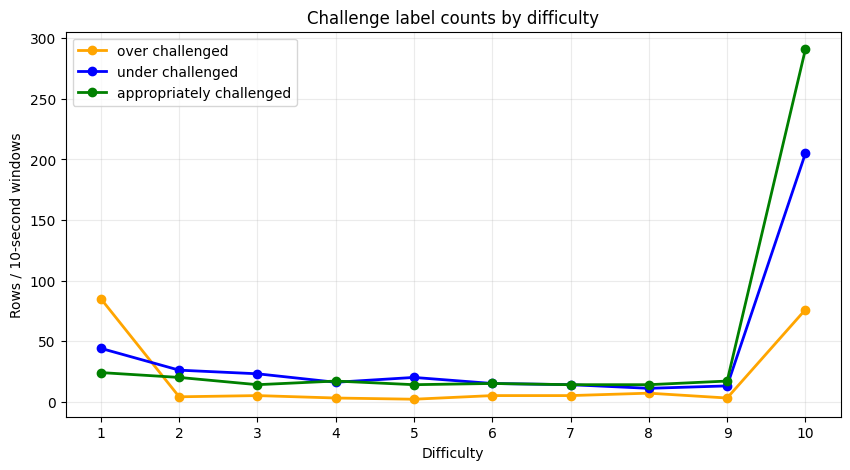

In [7]:
difficulty_label_counts = pd.crosstab(windows["difficulty"], windows["challenge_label"], margins=True)
difficulty_label_share = pd.crosstab(windows["difficulty"], windows["challenge_label"], normalize="index").round(3)
display(difficulty_label_counts)
display(difficulty_label_share)

try:
    import matplotlib.pyplot as plt

    plot_counts = pd.crosstab(windows["difficulty"], windows["challenge_label"]).reindex(range(1, 11), fill_value=0)
    colors = {
        "over_challenged": "orange",
        "under_challenged": "blue",
        "appropriately_challenged": "green",
    }

    fig, ax = plt.subplots(figsize=(10, 5))
    for label, color in colors.items():
        if label in plot_counts:
            ax.plot(
                plot_counts.index,
                plot_counts[label],
                marker="o",
                linewidth=2,
                color=color,
                label=label.replace("_", " "),
            )

    ax.set_title("Challenge label counts by difficulty")
    ax.set_xlabel("Difficulty")
    ax.set_ylabel("Rows / 10-second windows")
    ax.set_xticks(range(1, 11))
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()
except ImportError:
    print("matplotlib is not installed in this environment; skipping challenge-label line chart.")
